# Resident Risk of Regression Prediction
Using real Lighthouse data to estimate which residents are at elevated risk of regression and to assign a continuous regression-risk score.

## 1. Problem Framing
This pipeline uses real resident, health, education, incident, visitation, process-recording, and intervention-plan data. It builds a **resident-level snapshot** using historical information and predicts two outcomes:

- **`regression_score`**: a continuous 0–100 composite risk score
- **`high_risk`**: a binary flag where higher scores indicate elevated risk

The score is engineered from later observed outcomes, while the features come from earlier information, so the model is predicting forward-looking risk rather than simply re-labeling the same records.

## 2. Load Real Lighthouse Data
Try the database helper first. If the database is unavailable, fall back to the uploaded ZIP file.

In [2]:
from pathlib import Path
import zipfile
import warnings
import numpy as np
import pandas as pd

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
warnings.filterwarnings("ignore")

from pythondbconnection import importTableFromDb


residents = importTableFromDb("dbo.residents")
health = importTableFromDb("dbo.health_wellbeing_records")
education = importTableFromDb("dbo.education_records")
incidents = importTableFromDb("dbo.incident_reports")
process_recordings = importTableFromDb("dbo.process_recordings")
visits = importTableFromDb("dbo.home_visitations")
plans = importTableFromDb("dbo.intervention_plans")



for df_name, df in {
    "residents": residents,
    "health": health,
    "education": education,
    "incidents": incidents,
    "process_recordings": process_recordings,
    "visits": visits,
    "plans": plans,
}.items():
    print(df_name, df.shape)


residents (60, 49)
health (534, 14)
education (534, 10)
incidents (100, 12)
process_recordings (2810, 15)
visits (1337, 14)
plans (180, 11)


## 3. Clean Dates and Build Resident Anchors
We create an **anchor date** per resident. Features are built from data up to the anchor date, and the target score is built from data after the anchor date. This gives the model a forward-looking prediction task.

In [3]:

# Date cleanup
date_cols = {
    "residents": ["date_of_birth", "date_of_admission", "date_closed", "created_at"],
    "health": ["record_date"],
    "education": ["record_date"],
    "incidents": ["incident_date", "resolution_date"],
    "process_recordings": ["session_date"],
    "visits": ["visit_date"],
    "plans": ["target_date", "case_conference_date", "created_at", "updated_at"],
}

for col in date_cols["residents"]:
    if col in residents.columns:
        residents[col] = pd.to_datetime(residents[col], errors="coerce")
for col in date_cols["health"]:
    if col in health.columns:
        health[col] = pd.to_datetime(health[col], errors="coerce")
for col in date_cols["education"]:
    if col in education.columns:
        education[col] = pd.to_datetime(education[col], errors="coerce")
for col in date_cols["incidents"]:
    if col in incidents.columns:
        incidents[col] = pd.to_datetime(incidents[col], errors="coerce")
for col in date_cols["process_recordings"]:
    if col in process_recordings.columns:
        process_recordings[col] = pd.to_datetime(process_recordings[col], errors="coerce")
for col in date_cols["visits"]:
    if col in visits.columns:
        visits[col] = pd.to_datetime(visits[col], errors="coerce")
for col in date_cols["plans"]:
    if col in plans.columns:
        plans[col] = pd.to_datetime(plans[col], errors="coerce")

# Standardize ID types
for df in [residents, health, education, incidents, process_recordings, visits, plans]:
    df["resident_id"] = pd.to_numeric(df["resident_id"], errors="coerce")

# Gather per-resident event dates
event_frames = [
    health[["resident_id", "record_date"]].rename(columns={"record_date": "event_date"}),
    education[["resident_id", "record_date"]].rename(columns={"record_date": "event_date"}),
    incidents[["resident_id", "incident_date"]].rename(columns={"incident_date": "event_date"}),
    process_recordings[["resident_id", "session_date"]].rename(columns={"session_date": "event_date"}),
    visits[["resident_id", "visit_date"]].rename(columns={"visit_date": "event_date"}),
    plans[["resident_id", "created_at"]].rename(columns={"created_at": "event_date"}),
]
events = pd.concat(event_frames, ignore_index=True)
events = events.dropna(subset=["resident_id", "event_date"])

activity = events.groupby("resident_id")["event_date"].agg(["min", "max"]).reset_index()
activity.columns = ["resident_id", "first_event_date", "last_event_date"]

base = residents.merge(activity, on="resident_id", how="left")

# Fallbacks when event coverage is sparse
base["first_event_date"] = base["first_event_date"].fillna(base["date_of_admission"]).fillna(base["created_at"])
base["last_event_date"] = base["last_event_date"].fillna(base["date_closed"]).fillna(base["created_at"]).fillna(pd.Timestamp.today().normalize())

# Anchor date: 60% into the resident's observed timeline
span_days = (base["last_event_date"] - base["first_event_date"]).dt.days.clip(lower=30)
base["anchor_date"] = base["first_event_date"] + pd.to_timedelta((span_days * 0.60).round().astype(int), unit="D")
base["anchor_date"] = base[["anchor_date", "last_event_date"]].min(axis=1)
base["anchor_date"] = base["anchor_date"].fillna(base["date_of_admission"]).fillna(base["created_at"])
base[["resident_id", "first_event_date", "anchor_date", "last_event_date"]].head()


,resident_id,first_event_date,anchor_date,last_event_date
0,1,2023-10-01,2025-03-10,2026-02-23
1,2,2023-03-01,2024-04-08,2025-01-03
2,3,2024-05-01,2025-05-30,2026-02-16
3,4,2024-09-01,2025-07-21,2026-02-22
4,5,2024-01-01,2024-06-10,2024-09-25


## 4. Engineer Historical Features
These features summarize what we know **up to the anchor date**. They represent a resident's history, engagement, wellbeing, stability, and risk indicators before the later outcomes are observed.

In [4]:

# Resident-level base features
risk_map = {"Low": 1, "Medium": 2, "High": 3, "Critical": 4}
base["initial_risk_num"] = base["initial_risk_level"].map(risk_map)
base["current_risk_num"] = base["current_risk_level"].map(risk_map)

age_from_dob = ((base["anchor_date"] - base["date_of_birth"]).dt.days / 365.25).round(1)
base["age_at_anchor"] = age_from_dob.fillna(pd.to_numeric(base.get("present_age"), errors="coerce"))
base["days_since_admission"] = (base["anchor_date"] - base["date_of_admission"]).dt.days.clip(lower=0)
base["is_active_case"] = (base["case_status"] == "Active").astype(int)
base["has_special_needs_flag"] = base["has_special_needs"].fillna(False).astype(int)
base["is_pwd_flag"] = base["is_pwd"].fillna(False).astype(int)

def build_pre_anchor_agg(source_df, date_col, agg_dict):
    tmp = base[["resident_id", "anchor_date"]].merge(source_df, on="resident_id", how="left")
    tmp = tmp[tmp[date_col].notna() & (tmp[date_col] <= tmp["anchor_date"])]
    if tmp.empty:
        return pd.DataFrame({"resident_id": base["resident_id"]})
    return tmp.groupby("resident_id").agg(**agg_dict).reset_index()

health_pre = build_pre_anchor_agg(
    health,
    "record_date",
    {
        "health_obs_count": ("health_record_id", "count"),
        "health_general_mean": ("general_health_score", "mean"),
        "health_general_last": ("general_health_score", "last"),
        "nutrition_mean": ("nutrition_score", "mean"),
        "sleep_mean": ("sleep_quality_score", "mean"),
        "energy_mean": ("energy_level_score", "mean"),
        "bmi_last": ("bmi", "last"),
        "medical_check_rate": ("medical_checkup_done", "mean"),
        "psych_check_rate": ("psychological_checkup_done", "mean"),
    }
)

edu_pre = build_pre_anchor_agg(
    education,
    "record_date",
    {
        "edu_obs_count": ("education_record_id", "count"),
        "attendance_mean": ("attendance_rate", "mean"),
        "attendance_last": ("attendance_rate", "last"),
        "progress_mean": ("progress_percent", "mean"),
        "progress_last": ("progress_percent", "last"),
        "completed_programs": ("completion_status", lambda s: int((pd.Series(s) == "Completed").sum())),
        "inprogress_programs": ("completion_status", lambda s: int((pd.Series(s) == "InProgress").sum())),
    }
)

proc_pre = build_pre_anchor_agg(
    process_recordings,
    "session_date",
    {
        "session_count": ("recording_id", "count"),
        "avg_session_duration": ("session_duration_minutes", "mean"),
        "progress_noted_rate": ("progress_noted", "mean"),
        "concerns_flagged_rate": ("concerns_flagged", "mean"),
        "referral_rate": ("referral_made", "mean"),
        "negative_end_emotion_rate": ("emotional_state_end", lambda s: pd.Series(s).isin(["Sad", "Distressed", "Angry"]).mean()),
    }
)

inc_pre = build_pre_anchor_agg(
    incidents,
    "incident_date",
    {
        "incident_count": ("incident_id", "count"),
        "high_severity_incidents": ("severity", lambda s: int((pd.Series(s) == "High").sum())),
        "unresolved_incidents": ("resolved", lambda s: int((pd.Series(s).astype('boolean').fillna(False) == False).sum())),
        "follow_up_incidents": ("follow_up_required", "sum"),
    }
)

visit_pre = build_pre_anchor_agg(
    visits,
    "visit_date",
    {
        "visit_count": ("visitation_id", "count"),
        "safety_concerns_noted_count": ("safety_concerns_noted", "sum"),
        "follow_up_needed_count": ("follow_up_needed", "sum"),
        "favorable_visit_rate": ("visit_outcome", lambda s: pd.Series(s).eq("Favorable").mean()),
        "family_cooperation_good_rate": ("family_cooperation_level", lambda s: pd.Series(s).isin(["High", "Very High"]).mean()),
    }
)

plans_pre = build_pre_anchor_agg(
    plans,
    "created_at",
    {
        "plan_count": ("plan_id", "count"),
        "achieved_plans": ("status", lambda s: int((pd.Series(s) == "Achieved").sum())),
        "on_hold_plans": ("status", lambda s: int((pd.Series(s) == "On Hold").sum())),
        "in_progress_plans": ("status", lambda s: int((pd.Series(s) == "In Progress").sum())),
    }
)

dataset = base[[
    "resident_id", "anchor_date", "age_at_anchor", "days_since_admission",
    "sex", "case_status", "case_category", "reintegration_type",
    "initial_risk_num", "is_active_case", "has_special_needs_flag", "is_pwd_flag",
    "family_is_4ps", "family_solo_parent", "family_indigenous",
    "family_parent_pwd", "family_informal_settler"
]].copy()

for feat_df in [health_pre, edu_pre, proc_pre, inc_pre, visit_pre, plans_pre]:
    dataset = dataset.merge(feat_df, on="resident_id", how="left")

dataset.head()


,resident_id,anchor_date,age_at_anchor,days_since_admission,sex,case_status,case_category,reintegration_type,initial_risk_num,is_active_case,...,follow_up_incidents,visit_count,safety_concerns_noted_count,follow_up_needed_count,favorable_visit_rate,family_cooperation_good_rate,plan_count,achieved_plans,on_hold_plans,in_progress_plans
0,1,2025-03-10,16.5,510,F,Active,Neglected,Foster Care,4,1,...,0,28.0,5,13,0.392857,0.0,3,0,2,1
1,2,2024-04-08,16.0,387,F,Closed,Surrendered,Family Reunification,2,0,...,NaN,18.0,5,9,0.444444,0.0,3,1,1,0
2,3,2025-05-30,18.3,371,F,Active,Surrendered,Foster Care,2,1,...,2,21.0,11,9,0.333333,0.0,3,0,1,0
3,4,2025-07-21,13.1,297,F,Active,Neglected,None,3,1,...,0,8.0,2,2,0.625000,0.0,3,0,0,2
4,5,2024-06-10,15.1,152,F,Transferred,Surrendered,Family Reunification,2,0,...,True,8.0,2,3,0.375000,0.0,3,1,0,2


## 5. Build the Real Regression Target
The target score is built from **after-anchor outcomes**. Higher scores indicate worse later wellbeing, more incidents, more concerns, and poorer stability after the historical feature window.

In [5]:

def build_post_anchor_agg(source_df, date_col, agg_dict):
    tmp = base[["resident_id", "anchor_date", "last_event_date"]].merge(source_df, on="resident_id", how="left")
    tmp = tmp[tmp[date_col].notna() & (tmp[date_col] > tmp["anchor_date"])]
    if tmp.empty:
        return pd.DataFrame({"resident_id": base["resident_id"]})
    return tmp.groupby("resident_id").agg(**agg_dict).reset_index()

health_post = build_post_anchor_agg(
    health,
    "record_date",
    {
        "post_health_general_mean": ("general_health_score", "mean"),
        "post_sleep_mean": ("sleep_quality_score", "mean"),
        "post_energy_mean": ("energy_level_score", "mean"),
        "post_nutrition_mean": ("nutrition_score", "mean"),
    }
)

edu_post = build_post_anchor_agg(
    education,
    "record_date",
    {
        "post_progress_mean": ("progress_percent", "mean"),
        "post_attendance_mean": ("attendance_rate", "mean"),
    }
)

proc_post = build_post_anchor_agg(
    process_recordings,
    "session_date",
    {
        "post_concerns_rate": ("concerns_flagged", "mean"),
        "post_referral_rate": ("referral_made", "mean"),
        "post_negative_end_emotion_rate": ("emotional_state_end", lambda s: pd.Series(s).isin(["Sad", "Distressed", "Angry"]).mean()),
    }
)

inc_post = build_post_anchor_agg(
    incidents,
    "incident_date",
    {
        "post_incident_count": ("incident_id", "count"),
        "post_high_severity_count": ("severity", lambda s: int((pd.Series(s) == "High").sum())),
        "post_unresolved_count": ("resolved", lambda s: int((pd.Series(s).astype('boolean').fillna(False) == False).sum())),
    }
)

visit_post = build_post_anchor_agg(
    visits,
    "visit_date",
    {
        "post_safety_concern_rate": ("safety_concerns_noted", "mean"),
        "post_followup_rate": ("follow_up_needed", "mean"),
        "post_favorable_visit_rate": ("visit_outcome", lambda s: pd.Series(s).eq("Favorable").mean()),
    }
)

target_df = base[["resident_id", "current_risk_num"]].copy()
for feat_df in [health_post, edu_post, proc_post, inc_post, visit_post]:
    target_df = target_df.merge(feat_df, on="resident_id", how="left")

# Normalize missing post-window fields conservatively
for c in target_df.columns:
    if c != "resident_id":
        if target_df[c].dtype.kind in "biufc":
            target_df[c] = target_df[c].fillna(target_df[c].median() if target_df[c].notna().any() else 0)

# Composite 0-100 regression score
# Higher is worse.
score = (
    15 * (5 - target_df["post_health_general_mean"].clip(0, 5)) / 5 +
    10 * (5 - target_df["post_sleep_mean"].clip(0, 5)) / 5 +
    10 * (5 - target_df["post_energy_mean"].clip(0, 5)) / 5 +
    10 * (100 - target_df["post_progress_mean"].clip(0, 100)) / 100 +
    8  * (1 - target_df["post_attendance_mean"].clip(0, 1)) +
    12 * target_df["post_concerns_rate"].clip(0, 1) +
    8  * target_df["post_referral_rate"].clip(0, 1) +
    7  * target_df["post_negative_end_emotion_rate"].clip(0, 1) +
    8  * np.minimum(target_df["post_incident_count"], 4) / 4 +
    6  * np.minimum(target_df["post_high_severity_count"], 3) / 3 +
    6  * np.minimum(target_df["post_unresolved_count"], 3) / 3 +
    5  * target_df["post_safety_concern_rate"].clip(0, 1) +
    3  * target_df["post_followup_rate"].clip(0, 1) +
    6  * (1 - target_df["post_favorable_visit_rate"].clip(0, 1)) +
    4  * (target_df["current_risk_num"].fillna(2) - 1) / 3
)

target_df["regression_score"] = (score * 100 / score.max()).clip(0, 100)
target_df["high_risk"] = (target_df["regression_score"] >= 60).astype(int)

dataset = dataset.merge(target_df[["resident_id", "regression_score", "high_risk"]], on="resident_id", how="left")
dataset[["resident_id", "regression_score", "high_risk"]].head()


,resident_id,regression_score,high_risk
0,1,86.505907,1
1,2,74.64398,1
2,3,66.496653,1
3,4,87.766291,1
4,5,58.744518,0


## 6. Prepare Features and Splits
We keep both regression and binary targets. Numeric and categorical features are modeled through sklearn pipelines.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Clean all-NaN columns if any remain in the full dataset
dataset = dataset.dropna(axis=1, how="all").copy()

TARGET_REG = "regression_score"
TARGET_CLS = "high_risk"

drop_cols = ["resident_id", "anchor_date", TARGET_REG, TARGET_CLS]
feature_df = dataset.drop(columns=[c for c in drop_cols if c in dataset.columns]).copy()

X = feature_df
y_reg = dataset[TARGET_REG].copy()
y_cls = dataset[TARGET_CLS].copy()

# Remove rows with missing targets before splitting
valid_mask = y_reg.notna() & y_cls.notna()
X = X.loc[valid_mask].copy()
y_reg = y_reg.loc[valid_mask].copy()
y_cls = y_cls.loc[valid_mask].copy()

X_train, X_test, y_reg_train, y_reg_test, y_cls_train, y_cls_test = train_test_split(
    X, y_reg, y_cls, test_size=0.25, random_state=RANDOM_STATE, stratify=y_cls
)

# Drop columns that are entirely missing in training data
all_nan_cols = X_train.columns[X_train.isna().all()].tolist()
if all_nan_cols:
    print("Dropping all-NaN training columns:", all_nan_cols)
    X_train = X_train.drop(columns=all_nan_cols)
    X_test = X_test.drop(columns=all_nan_cols, errors="ignore")

# Rebuild feature lists AFTER dropping bad columns
numeric_features = X_train.select_dtypes(include=["number", "bool"]).columns.tolist()
categorical_features = [c for c in X_train.columns if c not in numeric_features]

preprocessor_for_logreg = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features),
    ],
    remainder="drop"
)

preprocessor_for_tree = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features),
    ],
    remainder="drop"
)

print("Modeling rows:", len(X))
print("High-risk rate:", round(y_cls.mean(), 3))
print("Training columns:", X_train.shape[1])
print("NaNs in y_reg_train:", y_reg_train.isna().sum())
X_train.head()

Modeling rows: 57
High-risk rate: 0.825
Training columns: 50
NaNs in y_reg_train: 0


,age_at_anchor,days_since_admission,sex,case_status,case_category,reintegration_type,initial_risk_num,is_active_case,has_special_needs_flag,is_pwd_flag,...,follow_up_incidents,visit_count,safety_concerns_noted_count,follow_up_needed_count,favorable_visit_rate,family_cooperation_good_rate,plan_count,achieved_plans,on_hold_plans,in_progress_plans
17,15.7,215,F,Closed,Neglected,Family Reunification,2,0,0,0,...,NaN,11.0,5,7,0.181818,0.0,3,0,0,1
43,15.4,192,F,Closed,Foundling,Adoption (Inter-Country),2,0,0,0,...,True,7.0,1,1,0.571429,0.0,3,0,1,0
33,15.2,176,F,Closed,Abandoned,Family Reunification,3,0,0,0,...,True,8.0,2,1,0.625000,0.0,3,0,2,1
5,18.7,536,F,Active,Foundling,Family Reunification,3,1,0,0,...,NaN,24.0,5,12,0.291667,0.0,3,0,1,1
29,15.9,334,F,Transferred,Abandoned,Independent Living,4,0,0,0,...,False,18.0,10,12,0.222222,0.0,3,0,0,3


## 7. Exploration
A quick look at the regression-score distribution and how it lines up with a few interpretable features.

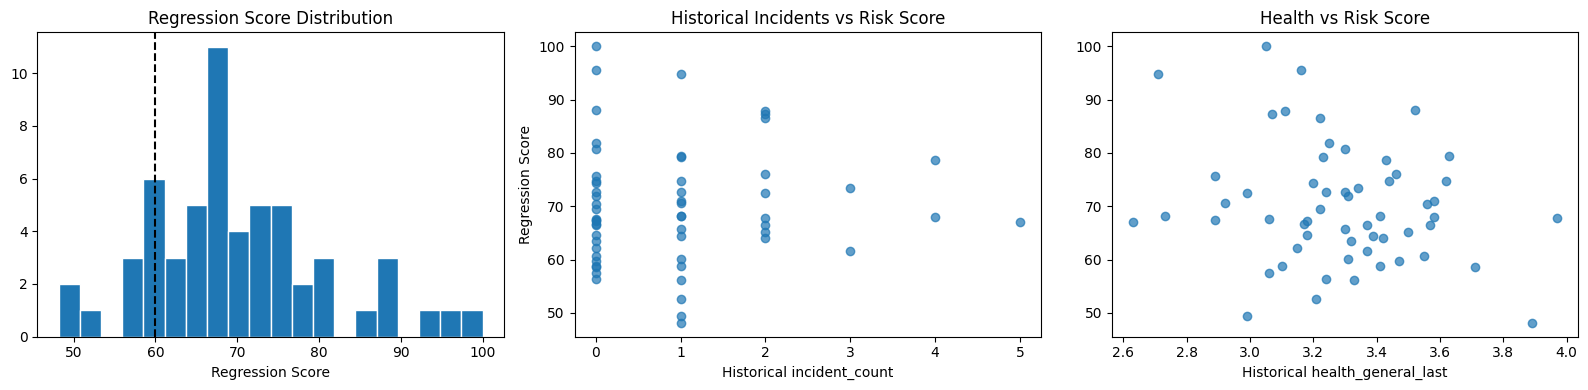

In [7]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(dataset["regression_score"], bins=20, edgecolor="white")
axes[0].axvline(60, linestyle="--", color="black")
axes[0].set_title("Regression Score Distribution")
axes[0].set_xlabel("Regression Score")

axes[1].scatter(dataset["incident_count"].fillna(0), dataset["regression_score"], alpha=0.7)
axes[1].set_title("Historical Incidents vs Risk Score")
axes[1].set_xlabel("Historical incident_count")
axes[1].set_ylabel("Regression Score")

axes[2].scatter(dataset["health_general_last"].fillna(dataset["health_general_mean"]), dataset["regression_score"], alpha=0.7)
axes[2].set_title("Health vs Risk Score")
axes[2].set_xlabel("Historical health_general_last")

plt.tight_layout()
plt.show()


## 8. Modeling
Train a regression model for the continuous score and a classifier for the high-risk flag.

In [8]:

from sklearn.ensemble import GradientBoostingRegressor, RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Regression model
reg_pipe = Pipeline([
    ("preprocessor", preprocessor_for_tree),
    ("model", GradientBoostingRegressor(
        n_estimators=250,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE,
    )),
])

reg_pipe.fit(X_train, y_reg_train)
y_reg_pred = reg_pipe.predict(X_test)

r2 = r2_score(y_reg_test, y_reg_pred)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
mae = mean_absolute_error(y_reg_test, y_reg_pred)

print(f"Regression — R²: {r2:.4f}")
print(f"Regression — RMSE: {rmse:.2f}")
print(f"Regression — MAE: {mae:.2f}")

# Classification models
models = {
    "Balanced Logistic Regression": Pipeline([
        ("preprocessor", preprocessor_for_logreg),
        ("model", LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            C=0.7,
            random_state=RANDOM_STATE,
        )),
    ]),
    "Balanced Random Forest": Pipeline([
        ("preprocessor", preprocessor_for_tree),
        ("model", RandomForestClassifier(
            n_estimators=500,
            random_state=RANDOM_STATE,
            class_weight="balanced_subsample",
            min_samples_leaf=2,
            max_features="sqrt",
            n_jobs=-1,
        )),
    ]),
    "Balanced Extra Trees": Pipeline([
        ("preprocessor", preprocessor_for_tree),
        ("model", ExtraTreesClassifier(
            n_estimators=600,
            random_state=RANDOM_STATE,
            class_weight="balanced",
            min_samples_leaf=2,
            max_features="sqrt",
            n_jobs=-1,
        )),
    ]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []

for name, pipe in models.items():
    roc = cross_val_score(pipe, X_train, y_cls_train, cv=cv, scoring="roc_auc").mean()
    ap = cross_val_score(pipe, X_train, y_cls_train, cv=cv, scoring="average_precision").mean()
    results.append({"model": name, "cv_roc_auc": roc, "cv_ap": ap})

results_df = pd.DataFrame(results).sort_values(["cv_roc_auc", "cv_ap"], ascending=False)
results_df


Regression — R²: -0.1538
Regression — RMSE: 12.14
Regression — MAE: 10.14


,model,cv_roc_auc,cv_ap
2,Balanced Extra Trees,0.728571,0.913515
1,Balanced Random Forest,0.671429,0.893118
0,Balanced Logistic Regression,0.571429,0.868798


## 9. Fit Best Classifier and Tune the Threshold
We tune the decision threshold on the training set and then evaluate on the holdout test set.

In [9]:

from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve

best_model_name = results_df.iloc[0]["model"]
best_pipe = models[best_model_name]
best_pipe.fit(X_train, y_cls_train)

train_proba = best_pipe.predict_proba(X_train)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_cls_train, train_proba)

# Threshold chosen by best F1 on training curve
f1_scores = (2 * precision[:-1] * recall[:-1]) / np.maximum(precision[:-1] + recall[:-1], 1e-9)
best_threshold = float(thresholds[np.nanargmax(f1_scores)]) if len(thresholds) else 0.5

y_proba = best_pipe.predict_proba(X_test)[:, 1]
print("Best model:", best_model_name)
print("Chosen threshold:", round(best_threshold, 3))
print("Holdout ROC-AUC:", round(roc_auc_score(y_cls_test, y_proba) if y_cls_test.nunique() > 1 else np.nan, 4))
print("Holdout Average Precision:", round(average_precision_score(y_cls_test, y_proba), 4))


Best model: Balanced Extra Trees
Chosen threshold: 0.671
Holdout ROC-AUC: 0.4444
Holdout Average Precision: 0.8519


## 10. Final Evaluation
Evaluate the holdout high-risk classifier with ROC, precision-recall, and a confusion matrix.

              precision    recall  f1-score   support

  Lower Risk       0.00      0.00      0.00         3
   High Risk       0.73      0.67      0.70        12

    accuracy                           0.53        15
   macro avg       0.36      0.33      0.35        15
weighted avg       0.58      0.53      0.56        15



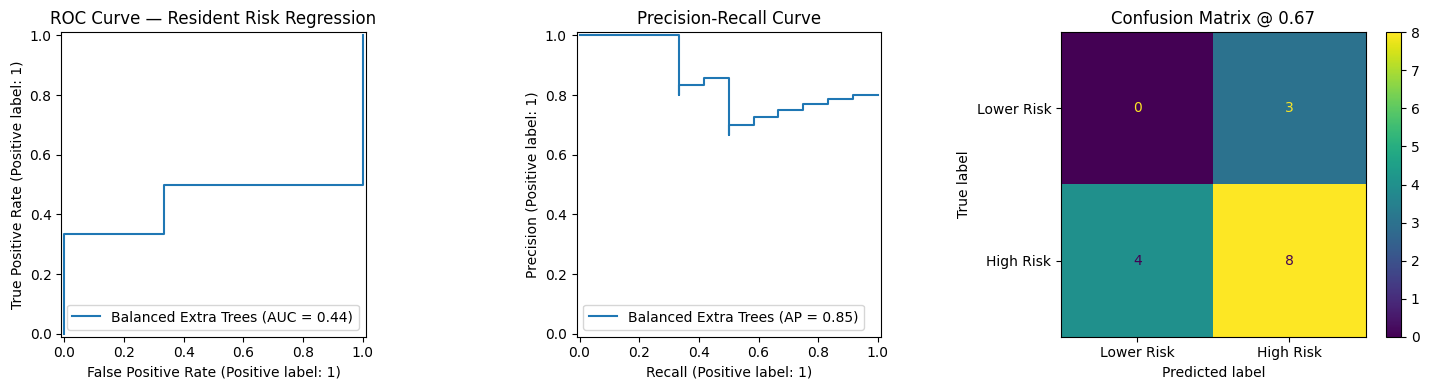

In [10]:

import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    ConfusionMatrixDisplay,
)

y_pred = (y_proba >= best_threshold).astype(int)

print(classification_report(y_cls_test, y_pred, target_names=["Lower Risk", "High Risk"]))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
RocCurveDisplay.from_predictions(y_cls_test, y_proba, ax=axes[0], name=best_model_name)
axes[0].set_title("ROC Curve — Resident Risk Regression")

PrecisionRecallDisplay.from_predictions(y_cls_test, y_proba, ax=axes[1], name=best_model_name)
axes[1].set_title("Precision-Recall Curve")

ConfusionMatrixDisplay.from_predictions(
    y_cls_test, y_pred, display_labels=["Lower Risk", "High Risk"], ax=axes[2]
)
axes[2].set_title(f"Confusion Matrix @ {best_threshold:.2f}")

plt.tight_layout()
plt.show()


## 11. Feature Importance
Inspect the most important drivers of the continuous regression score.

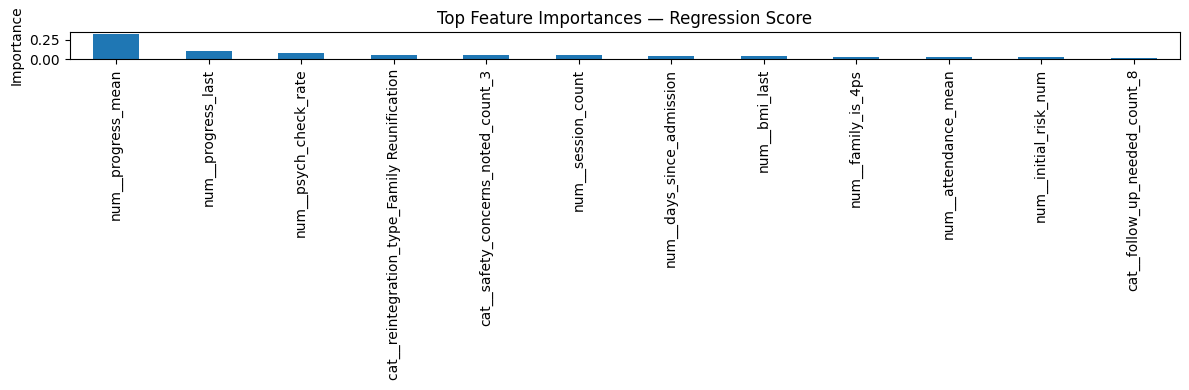

num__progress_mean                              0.331620
num__progress_last                              0.099720
num__psych_check_rate                           0.074737
cat__reintegration_type_Family Reunification    0.057747
cat__safety_concerns_noted_count_3              0.049484
num__session_count                              0.046716
num__days_since_admission                       0.035225
num__bmi_last                                   0.033629
num__family_is_4ps                              0.031887
num__attendance_mean                            0.030684
dtype: float64

In [11]:

# Extract transformed feature names from the trained regressor
feature_names = reg_pipe.named_steps["preprocessor"].get_feature_names_out()
importances = pd.Series(
    reg_pipe.named_steps["model"].feature_importances_,
    index=feature_names
).sort_values(ascending=False)

top_features = importances.head(12)
top_features.plot(kind="bar", figsize=(12, 4), title="Top Feature Importances — Regression Score")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

selected_features = list(X_train.columns)
top_features.head(10)


## 12. Save the Final Model
Save the best classification pipeline in the same standardized format used in the other project notebooks.

In [12]:

import pickle, os
import pandas as pd

os.makedirs("models", exist_ok=True)

# Keep feature list consistent
selected_features = list(X_train.columns)

# Final trained pipeline
final_model = best_pipe

# Save artifact in same format as the other pipelines
with open("models/resident_risk_regression_model.pkl", "wb") as f:
    pickle.dump({
        "model": final_model,
        "features": selected_features,
        "threshold": best_threshold if 'best_threshold' in globals() else 0.5,
        "target_name": "high_risk"
    }, f)

print("Model saved to models/resident_risk_regression_model.pkl")

# Example scoring
new_residents = X_test[selected_features].iloc[:5].copy()
probs = final_model.predict_proba(new_residents)[:, 1]

new_residents["risk_probability"] = probs
new_residents["prediction"] = (probs >= (best_threshold if 'best_threshold' in globals() else 0.5)).astype(int)

new_residents["risk_tier"] = pd.cut(
    new_residents["risk_probability"],
    bins=[0, 0.4, 0.65, 1.0],
    labels=["Low", "Medium", "High"]
)

print(new_residents[["risk_probability", "prediction", "risk_tier"]])


Model saved to models/resident_risk_regression_model.pkl
    risk_probability  prediction risk_tier
24          0.954356           1      High
51          0.637949           0    Medium
28          0.682091           1      High
52          0.899311           1      High
46          0.690073           1      High
